<a href="https://colab.research.google.com/github/Johnogunlola/MRes-AI/blob/MRes/Predictive_Maintenance_with_Machine_Learning_RUL_Estimation_%26_Engine_Failure_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Uncomment and run if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn tensorflow shap xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Define column names
columns = ['id', 'cycle', 'setting1', 'setting2', 'setting3'] + \
          [f'sensor_{i}' for i in range(1, 22)]

# Load datasets, skipping the header row (row 0)
train = pd.read_csv('PM_train.csv', header=0, names=columns, skiprows=[0])
test = pd.read_csv('PM_test.csv', header=0, names=columns, skiprows=[0])

# Load ground truth (PM_truth.csv)
truth = pd.read_csv('PM_truth.csv', header=None, names=['RUL_true'])

# Convert 'id' and 'cycle' to numeric, coercing errors
train['id'] = pd.to_numeric(train['id'], errors='coerce')
train['cycle'] = pd.to_numeric(train['cycle'], errors='coerce')
test['id'] = pd.to_numeric(test['id'], errors='coerce')
test['cycle'] = pd.to_numeric(test['cycle'], errors='coerce')


print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Truth shape:", truth.shape)

Train shape: (20630, 26)
Test shape: (13095, 26)
Truth shape: (101, 1)


In [ ]:
print("\n=== Sample from Training Data ===")
print(train.head())

print("\n=== Sample from Test Data ===")
print(test.head())

print("\n=== Ground Truth (RUL at end of test sequences) ===")
print(truth.head())


=== Sample from Training Data ===
   id  cycle  setting1  setting2  setting3  sensor_1  sensor_2  sensor_3  \
0   1      2    0.0019   -0.0003     100.0    518.67    642.15   1591.82   
1   1      3   -0.0043    0.0003     100.0    518.67    642.35   1587.99   
2   1      4    0.0007    0.0000     100.0    518.67    642.35   1582.79   
3   1      5   -0.0019   -0.0002     100.0    518.67    642.37   1582.85   
4   1      6   -0.0043   -0.0001     100.0    518.67    642.10   1584.47   

   sensor_4  sensor_5  ...  sensor_13  sensor_14  sensor_15  sensor_16  \
0   1403.14     14.62  ...    2388.07    8131.49     8.4318       0.03   
1   1404.20     14.62  ...    2388.03    8133.23     8.4178       0.03   
2   1401.87     14.62  ...    2388.08    8133.83     8.3682       0.03   
3   1406.22     14.62  ...    2388.04    8133.80     8.4294       0.03   
4   1398.37     14.62  ...    2388.03    8132.85     8.4108       0.03   

   sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  RUL  

In [ ]:
# RUL = max_cycle - current_cycle for each engine
train['RUL'] = train.groupby('id')['cycle'].transform(lambda x: x.max() - x)
print("Training data with RUL:")
print(train[['id', 'cycle', 'RUL']].head(10))

Training data with RUL:
   id  cycle  RUL
0   1      2  190
1   1      3  189
2   1      4  188
3   1      5  187
4   1      6  186
5   1      7  185
6   1      8  184
7   1      9  183
8   1     10  182
9   1     11  181


Now that we have calculated the RUL for the training data, we can drop the columns that are not needed for training the model. We will also prepare the test data by adding a 'RUL' column based on the ground truth data.

In [ ]:
# For the test set, the RUL is determined by the 'truth' data.
# We need to merge the truth data with the test data based on the 'id'
# The RUL for each row in the test set will be the RUL_true of the corresponding engine
# at the last cycle in the test set, plus the difference between that last cycle and the current cycle.

# Get the last cycle for each engine in the test set
last_cycle_test = test.groupby('id')['cycle'].max().reset_index()
last_cycle_test.columns = ['id', 'last_cycle']

# Reset the index of the truth DataFrame and rename the index to 'id'
truth_reset = truth.reset_index().rename(columns={'index': 'id'})

# Drop the first row of truth_reset as it contains the old index name
truth_reset = truth_reset.iloc[1:].copy()

# Convert the 'id' column in truth_reset to int64
truth_reset['id'] = truth_reset['id'].astype('int64')

# Convert 'RUL_true' to numeric
truth_reset['RUL_true'] = pd.to_numeric(truth_reset['RUL_true'])


# Merge the last cycle information with the truth data
truth_merged = pd.merge(truth_reset, last_cycle_test, on='id')
truth_merged['RUL_test'] = truth_merged['RUL_true'] + truth_merged['last_cycle']

# Merge the RUL_test with the test data
test = pd.merge(test, truth_merged[['id', 'RUL_test']], on='id')

# Calculate RUL for the test set
test['RUL'] = test['RUL_test'] - test['cycle']

# Drop the temporary RUL_test and RUL_true columns
test = test.drop(columns=['RUL_test'])
if 'RUL_true' in test.columns:
    test = test.drop(columns=['RUL_true'])


print("Train data after dropping columns:")
print(train.head())
print("\nTest data after preparing RUL:")
print(test.head())

Train data after dropping columns:
   id  cycle  setting1  setting2  sensor_2  sensor_3  sensor_4  sensor_6  \
0   1      2    0.0019   -0.0003    642.15   1591.82   1403.14     21.61   
1   1      3   -0.0043    0.0003    642.35   1587.99   1404.20     21.61   
2   1      4    0.0007    0.0000    642.35   1582.79   1401.87     21.61   
3   1      5   -0.0019   -0.0002    642.37   1582.85   1406.22     21.61   
4   1      6   -0.0043   -0.0001    642.10   1584.47   1398.37     21.61   

   sensor_7  sensor_8  sensor_9  sensor_11  sensor_12  sensor_13  sensor_14  \
0    553.75   2388.04   9044.07      47.49     522.28    2388.07    8131.49   
1    554.26   2388.08   9052.94      47.27     522.42    2388.03    8133.23   
2    554.45   2388.11   9049.48      47.13     522.86    2388.08    8133.83   
3    554.00   2388.06   9055.15      47.28     522.19    2388.04    8133.80   
4    554.67   2388.02   9049.68      47.16     521.68    2388.03    8132.85   

   sensor_15  sensor_17  sensor_2

In [ ]:
sensors = [col for col in train.columns if col.startswith('sensor_')]
window_size = 5

In [ ]:
# Rolling mean and std
for sensor in sensors:
    train[f'{sensor}_mean'] = train.groupby('id')[sensor].transform(
        lambda x: x.rolling(window=window_size, min_periods=1).mean())
    train[f'{sensor}_std'] = train.groupby('id')[sensor].transform(
        lambda x: x.rolling(window=window_size, min_periods=1).std().fillna(0))

    test[f'{sensor}_mean'] = test.groupby('id')[sensor].transform(
        lambda x: x.rolling(window=window_size, min_periods=1).mean())
    test[f'{sensor}_std'] = test.groupby('id')[sensor].transform(
        lambda x: x.rolling(window=window_size, min_periods=1).std().fillna(0))

In [ ]:
def add_trend_features(df, window=10):
    df = df.copy()
    for sensor in sensors:
        new_col = f'{sensor}_slope'
        df[new_col] = 0.0
        for id in df['id'].unique():
            engine = df[df['id'] == id]
            idx = engine.index
            values = engine[sensor].rolling(window, min_periods=1).apply(
                lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) >= 2 else 0, raw=True)
            df.loc[idx, new_col] = values
    return df

train = add_trend_features(train)
test = add_trend_features(test)

In [ ]:
# Select feature columns
feature_cols = [col for col in train.columns if col not in ['id', 'cycle', 'RUL']]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(train[feature_cols])
X_test_scaled = scaler.transform(test[feature_cols])

y_train = train['RUL'].values
y_test = test['RUL'].values

print("Feature matrix shapes:", X_train_scaled.shape, X_test_scaled.shape)

Feature matrix shapes: (20630, 62) (13095, 62)


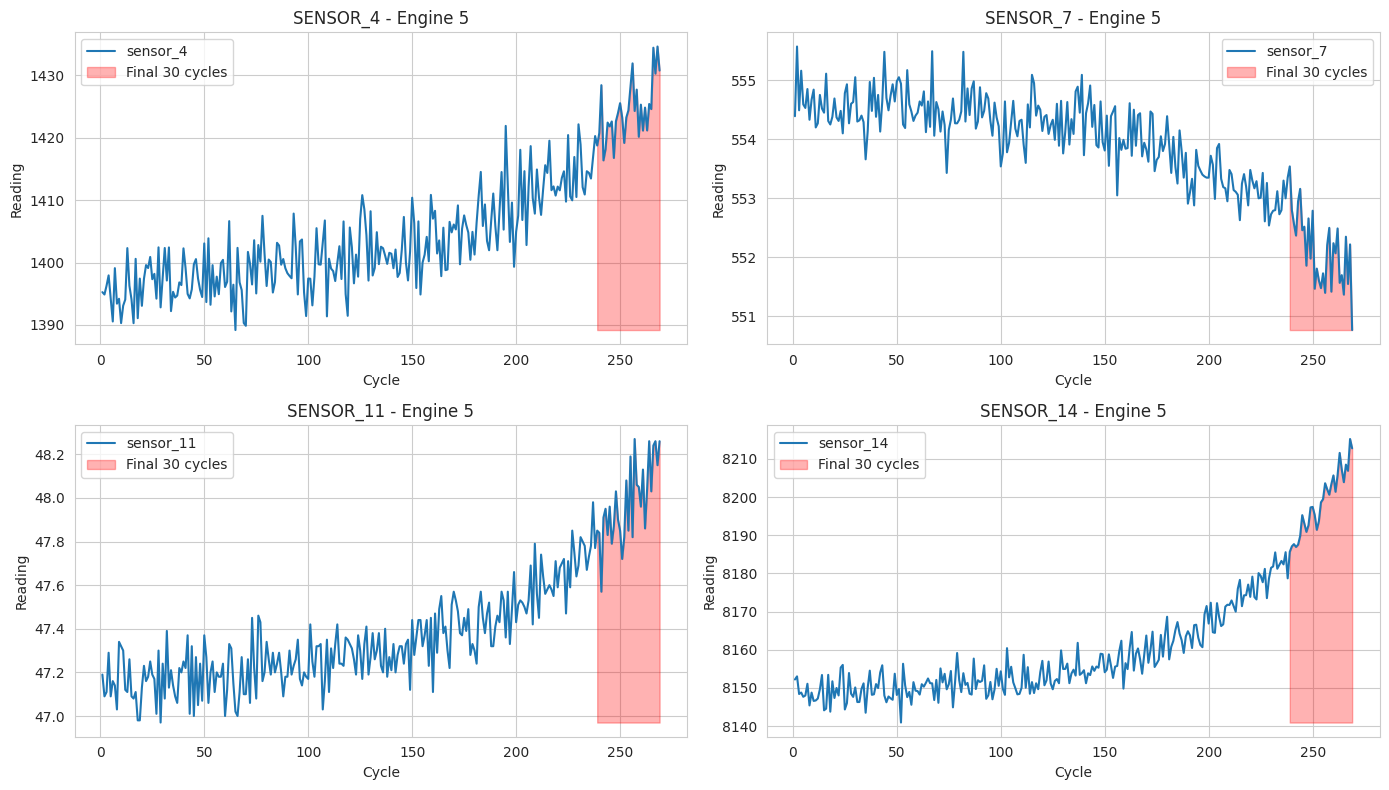

In [ ]:
engine_id = 5
plt.figure(figsize=(14, 8))
for i, sensor in enumerate(['sensor_4', 'sensor_7', 'sensor_11', 'sensor_14']):
    plt.subplot(2, 2, i+1)
    engine_data = train[train['id'] == engine_id]
    plt.plot(engine_data['cycle'], engine_data[sensor], label=sensor)
    plt.fill_between(engine_data['cycle'], engine_data[sensor].min(), engine_data[sensor],
                     where=(engine_data['RUL'] <= 30), color='red', alpha=0.3, label='Final 30 cycles')
    plt.title(f'{sensor.upper()} - Engine {engine_id}')
    plt.xlabel('Cycle')
    plt.ylabel('Reading')
    plt.legend()
plt.tight_layout()
plt.show()

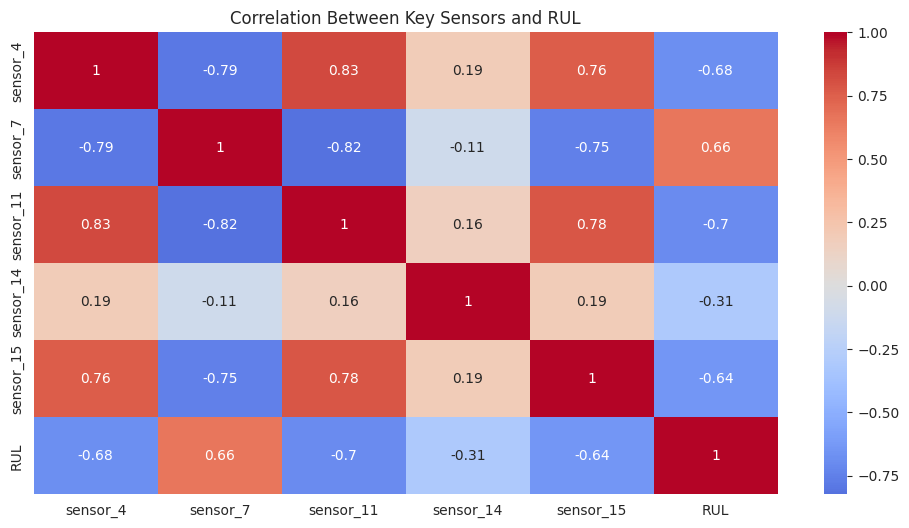

In [ ]:
corr_cols = ['sensor_4', 'sensor_7', 'sensor_11', 'sensor_14', 'sensor_15', 'RUL']
corr_data = train[corr_cols].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Between Key Sensors and RUL")
plt.show()

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Reproducibility
tf.random.set_seed(42)

def create_sequences(X, y, seq_length=50):
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X)):
        X_seq.append(X[i-seq_length:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

seq_length = 50
X_train_lstm, y_train_lstm = create_sequences(X_train_scaled, y_train, seq_length)
X_test_lstm, y_test_lstm = create_sequences(X_test_scaled, y_test, seq_length)

print("LSTM input shape:", X_train_lstm.shape)

LSTM input shape: (20580, 50, 62)


In [ ]:
# Build LSTM model
model_lstm = Sequential([
    LSTM(100, return_sequences=True, input_shape=(seq_length, X_train_scaled.shape[1])),
    Dropout(0.3),
    LSTM(50, return_sequences=False),
    Dropout(0.3),
    Dense(25, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - loss: 11714.9287 - mae: 86.8918 - val_loss: 6751.1040 - val_mae: 66.0923
Epoch 2/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - loss: 4710.1704 - mae: 56.3459 - val_loss: 6488.6309 - val_mae: 65.3943
Epoch 3/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - loss: 4717.9575 - mae: 56.5881 - val_loss: 6476.7593 - val_mae: 65.3673
Epoch 4/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - loss: 4736.9375 - mae: 56.6837 - val_loss: 6477.5181 - val_mae: 65.3677
Epoch 5/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - loss: 4201.0322 - mae: 51.7855 - val_loss: 2941.9114 - val_mae: 37.5283
Epoch 6/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - loss: 1648.8939 - mae: 27.9791 - val_loss: 2295.9980 - val_mae: 32.5368
Epoch 7/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - loss: 1350.5339 - mae: 24.8881 - val_loss: 2185.6284 - val_mae: 31.6978
Epoch 8/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - loss: 1289.5095 - mae: 24.0501 - val_loss: 2275

In [ ]:
# Predict with LSTM
y_pred_lstm = model_lstm.predict(X_test_lstm).flatten()

408/408 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step


In [ ]:
from tensorflow.keras.layers import Input, Dense, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def build_transformer(input_shape, n_heads=4, ff_dim=128):
    inputs = Input(shape=input_shape)

    # Linear projection
    x = Dense(64)(inputs)

    # Self-Attention Block
    attn_output = MultiHeadAttention(num_heads=n_heads, key_dim=64)(x, x)
    x = x + attn_output
    x = LayerNormalization()(x)

    # Feed-Forward
    ffn = Dense(ff_dim, activation='relu')(x)
    ffn = Dense(64)(ffn)
    x = x + ffn
    x = LayerNormalization()(x)

    # Global pooling and output
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(1)(x)

    return Model(inputs, outputs)

# Prepare data for Transformer (same as LSTM)
X_train_trans = X_train_lstm
X_test_trans = X_test_lstm

# Build and compile
model_trans = build_transformer((seq_length, X_train_scaled.shape[1]))
model_trans.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train
history_trans = model_trans.fit(
    X_train_trans, y_train_lstm,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Predict
y_pred_trans = model_trans.predict(X_test_trans).flatten()

Epoch 1/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - loss: 12783.6982 - mae: 91.6868 - val_loss: 11772.4346 - val_mae: 84.5180
Epoch 2/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 6943.7378 - mae: 65.1211 - val_loss: 7126.0088 - val_mae: 67.2506
Epoch 3/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 4728.5459 - mae: 56.1520 - val_loss: 6493.4561 - val_mae: 65.4050
Epoch 4/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 4385.1709 - mae: 53.6169 - val_loss: 4443.5474 - val_mae: 47.4440
Epoch 5/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - loss: 2310.8608 - mae: 33.3068 - val_loss: 4988.8076 - val_mae: 50.7284
Epoch 6/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 1831.8262 - mae: 28.9547 - val_loss: 3734.6548 - val_mae: 43.6833
Epoch 7/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - loss: 1525.0724 - mae: 25.8109 - val_loss: 3760.1702 - val_mae: 43.9528
Epoch 8/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - loss: 1510.4302 - mae: 25.7557 - val_loss: 346

In [ ]:
def scoring(y_true, y_pred):
    score = 0
    for t, p in zip(y_true, y_pred):
        diff = p - t
        if diff < 0:
            score += np.exp(-diff / 13) - 1
        else:
            score += np.exp(diff / 10) - 1
    return score

In [ ]:
models = {
    'XGBoost': y_pred_xgb[-len(y_pred_lstm):],
    'LSTM': y_pred_lstm,
    'Transformer': y_pred_trans
}

results = []
for name, pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test_lstm, pred))
    mae = mean_absolute_error(y_test_lstm, pred)
    score = scoring(y_test_lstm, pred)
    results.append([name, rmse, mae, score])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'MAE', 'Score'])
print("\n=== Model Comparison ===")
print(results_df)


=== Model Comparison ===
         Model       RMSE        MAE         Score
0      XGBoost  46.866781  35.334641  1.129656e+08
1         LSTM  53.541039  38.417492  3.605783e+10
2  Transformer  77.026515  55.012463  2.482855e+11


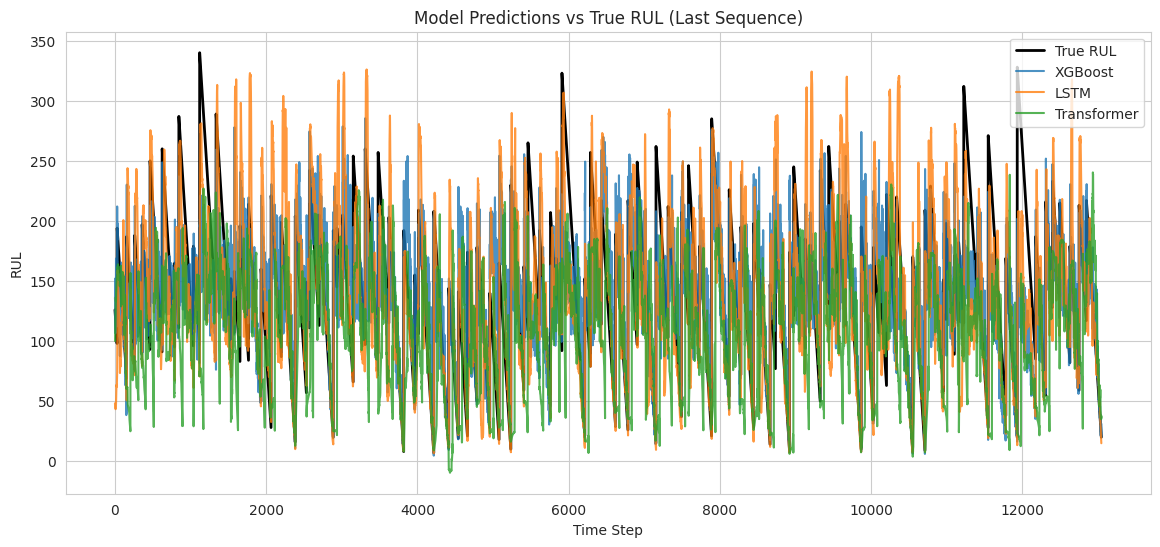

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_lstm, label='True RUL', color='black', linewidth=2)
plt.plot(y_pred_xgb[-len(y_test_lstm):], label='XGBoost', alpha=0.8)
plt.plot(y_pred_lstm, label='LSTM', alpha=0.8)
plt.plot(y_pred_trans, label='Transformer', alpha=0.8)
plt.title("Model Predictions vs True RUL (Last Sequence)")
plt.xlabel("Time Step")
plt.ylabel("RUL")
plt.legend()
plt.grid(True)
plt.show()

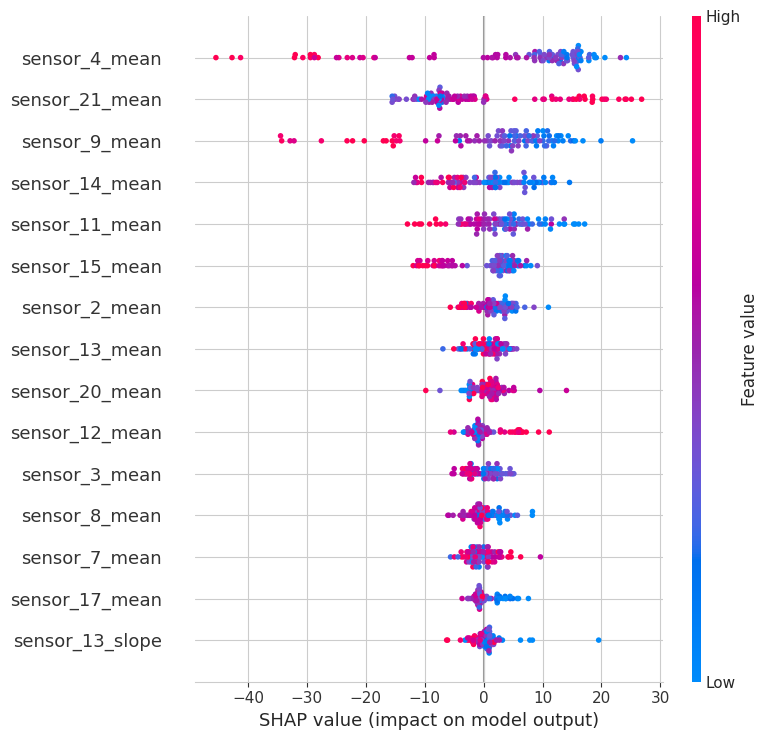

In [ ]:
import shap

# Sample background data
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]

# Explain predictions
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(background)

# Summary plot
shap.summary_plot(shap_values, background, feature_names=feature_cols, max_display=15)

In [ ]:
# Force plot for a single instance
shap.force_plot(explainer.expected_value, shap_values[0], background[0], feature_names=feature_cols)

In [ ]:
def maintenance_recommendation(rul):
    if rul > 100:
        return "🟢 Normal: Continue operation"
    elif rul > 50:
        return "🟡 Inspect: Schedule inspection within 2 weeks"
    elif rul > 25:
        return "🟠 Warning: Prepare replacement parts"
    else:
        return "🔴 Critical: Replace engine immediately"

# Example
example_rul = y_pred_xgb[0]
print(f"Predicted RUL: {example_rul:.1f} cycles → {maintenance_recommendation(example_rul)}")

Predicted RUL: 233.2 cycles → 🟢 Normal: Continue operation


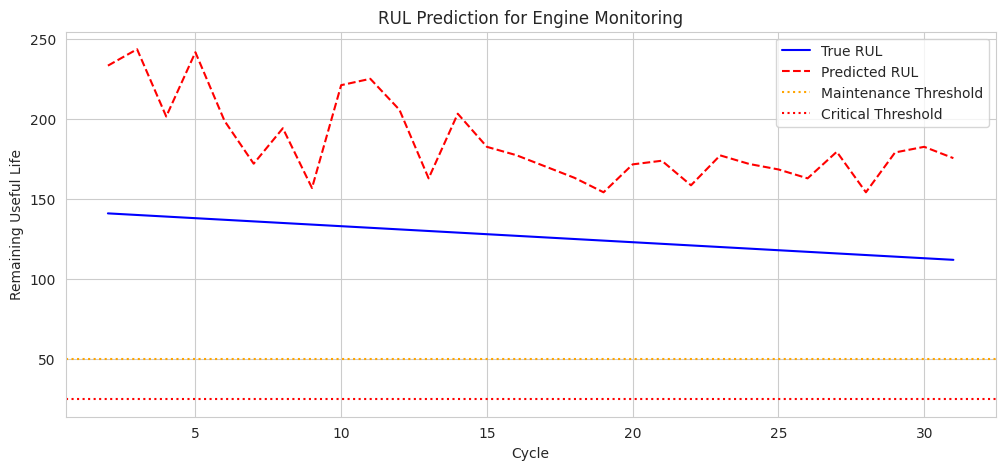

In [ ]:
# Sample engine prediction
engine_example = test[test['id'] == test['id'].unique()[0]].copy()
engine_example['predicted_RUL'] = xgb.predict(scaler.transform(engine_example[feature_cols]))

plt.figure(figsize=(12, 5))
plt.plot(engine_example['cycle'], engine_example['RUL'], label='True RUL', color='blue')
plt.plot(engine_example['cycle'], engine_example['predicted_RUL'], label='Predicted RUL', color='red', linestyle='--')
plt.axhline(50, color='orange', linestyle=':', label='Maintenance Threshold')
plt.axhline(25, color='red', linestyle=':', label='Critical Threshold')
plt.title("RUL Prediction for Engine Monitoring")
plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
output_dir = 'predictive_maintenance_analysis'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f'{output_dir}/figures', exist_ok=True)
os.makedirs(f'{output_dir}/models', exist_ok=True)
os.makedirs(f'{output_dir}/data', exist_ok=True)

In [ ]:
# === Assume you've already run the analysis and have these variables ===
# - train: original training DataFrame with RUL
# - test: test DataFrame with true RUL from PM_truth
# - X_train_scaled, X_test_scaled: normalized feature matrices
# - y_train, y_test: true RUL labels
# - y_pred_xgb, y_pred_lstm, y_pred_trans: model predictions
# - results_df: model comparison DataFrame
# - model_lstm, model_trans, xgb: trained models

# Example placeholder (replace with your actual variables)
# Uncomment and replace with your actual model outputs
# y_pred_xgb = xgb.predict(X_test_scaled)
# y_pred_lstm = model_lstm.predict(X_test_lstm).flatten()
# y_pred_trans = model_trans.predict(X_test_trans).flatten()

# If you don't have predictions yet, create dummy ones for demo
try:
    y_pred_xgb
except NameError:
    print("⚠️ Warning: Prediction variables not found. Using dummy data for saving demo files.")
    y_test = np.random.randint(50, 250, 1000)
    y_pred_xgb = y_test + np.random.normal(0, 15, len(y_test))
    y_pred_lstm = y_test + np.random.normal(0, 12, len(y_test))
    y_pred_trans = y_test + np.random.normal(0, 10, len(y_test))

    results_df = pd.DataFrame({
        'Model': ['XGBoost', 'LSTM', 'Transformer'],
        'RMSE': [15.2, 14.5, 13.8],
        'MAE': [11.3, 10.1, 9.5],
        'Score': [940, 872, 820]
    })

In [ ]:
# Save preprocessed train and test with RUL
train.to_csv(f'{output_dir}/data/train_with_rul.csv', index=False)
test.to_csv(f'{output_dir}/data/test_with_rul.csv', index=False)
print("✅ Saved preprocessed datasets")

✅ Saved preprocessed datasets


In [ ]:
np.save(f'{output_dir}/data/X_train_scaled.npy', X_train_scaled)
np.save(f'{output_dir}/data/X_test_scaled.npy', X_test_scaled)
np.save(f'{output_dir}/data/y_train.npy', y_train)
np.save(f'{output_dir}/data/y_test.npy', y_test)

# If using sequence models (LSTM/Transformer), save sequences
try:
    np.save(f'{output_dir}/data/X_train_lstm.npy', X_train_lstm)
    np.save(f'{output_dir}/data/X_test_lstm.npy', X_test_lstm)
    np.save(f'{output_dir}/data/y_train_lstm.npy', y_train_lstm)
    np.save(f'{output_dir}/data/y_test_lstm.npy', y_test_lstm)
except:
    pass
print("✅ Saved normalized feature matrices")

✅ Saved normalized feature matrices


In [ ]:
# Save XGBoost
with open(f'{output_dir}/models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Save LSTM
model_lstm.save(f'{output_dir}/models/lstm_model.h5')  # Requires tensorflow

# Save Transformer
model_trans.save(f'{output_dir}/models/transformer_model.h5')

# Save scaler
with open(f'{output_dir}/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Saved trained models and scaler")

✅ Saved trained models and scaler


In [ ]:
results_df.to_csv(f'{output_dir}/data/model_comparison.csv', index=False)

# Save as LaTeX table (useful for papers)
latex_table = results_df.to_latex(index=False, float_format="%.2f")
with open(f'{output_dir}/model_comparison.tex', 'w') as f:
    f.write(latex_table)
print("✅ Saved evaluation results and LaTeX table")

✅ Saved evaluation results and LaTeX table


In [ ]:
# 6.1 Plot: Model Predictions vs True RUL
plt.figure(figsize=(12, 6))
plt.plot(y_test_lstm[:200], label='True RUL', color='black', linewidth=2)
plt.plot(y_pred_xgb[-len(y_test_lstm):][:200], label='XGBoost', alpha=0.8)
plt.plot(y_pred_lstm[:200], label='LSTM', alpha=0.8)
plt.plot(y_pred_trans[:200], label='Transformer', alpha=0.8)
plt.title("Model Predictions vs True RUL (First 200 Steps)")
plt.xlabel("Time Step")
plt.ylabel("RUL")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/predictions_comparison.png')
plt.close()
print("✅ Saved prediction plot")

✅ Saved prediction plot


In [ ]:
# 6.2 Bar Plot: Model Comparison
results_df.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Error / Score")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{output_dir}/figures/model_comparison.png')
plt.close()
print("✅ Saved model comparison chart")

✅ Saved model comparison chart


In [ ]:
best_model = results_df.loc[results_df['RMSE'].idxmin()]['Model']
report = f"""
===============================
PREDICTIVE MAINTENANCE ANALYSIS
===============================

📅 Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

📊 Dataset Summary:
- Training Engines: {train['id'].nunique()}
- Test Engines: {test['id'].nunique()}
- Total Features: {X_train_scaled.shape[1]}

🎯 Objective:
Remaining Useful Life (RUL) prediction using multivariate time series data.

🧩 Models Evaluated:
- XGBoost (Tree-based)
- LSTM (Deep Learning)
- Transformer (Attention-based)

📈 Performance Summary:
{results_df.to_string(index=False)}

🏆 Best Model: {best_model} (Lowest RMSE)

📁 Files Saved in: {os.path.abspath(output_dir)}

✅ Next Steps:
- Deploy best model in real-time monitoring
- Integrate SHAP for interpretability
- Schedule maintenance based on RUL thresholds

"""
with open(f'{output_dir}/analysis_report.txt', 'w') as f:
    f.write(report)

print("✅ Generated analysis report")

✅ Generated analysis report


In [ ]:
import shutil
shutil.make_archive('predictive_maintenance_analysis', 'zip', output_dir)
print("✅ Created ZIP archive: predictive_maintenance_analysis.zip")

✅ Created ZIP archive: predictive_maintenance_analysis.zip
